# 03b — RAG Avanzado: Re-ranking, Evaluación y Técnicas Avanzadas

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque3/03b-rag-avanzado.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 3 — Aplicaciones**. Se recomienda
> haber completado los [Bloques 1](../bloque1/01-fundamentos.qmd) y
> [2](../bloque2/02-orquestacion.qmd) primero.

In [1]:
!pip install -q chromadb sentence-transformers flashrank langchain langchain-community langchain-text-splitters ragas datasets fpdf2 pypdf python-dotenv openai scikit-learn

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas que usan LLM mostrarán este mensaje hasta que configures la clave.")
else:
    client = OpenAI(base_url=LLM_URL, api_key=LLM_KEY)
    print("✅ Cliente OpenAI configurado.")

✅ Cliente OpenAI configurado.

## RAG Avanzado

### De RAG naive a RAG avanzado

En el [HPD 1](../evaluables/hpd1-embeddings.qmd) construiste un pipeline
RAG básico: cargar PDFs, trocearlos en chunks, generar embeddings,
indexar en Chroma y buscar por similitud coseno. Funciona, pero tiene
limitaciones:

- El retriever semántico (bi-encoder) es **rápido pero impreciso**:
  confunde frases con palabras similares pero significado distinto
- No hay forma de **medir la calidad** del sistema más allá de “a ojo”
- Solo busca en **una fuente** de datos

**RAG es como buscar en una biblioteca con un índice alfabético. RAG
avanzado es como tener un bibliotecario que primero busca los capítulos
relevantes y luego los relee con lupa antes de responderte.**

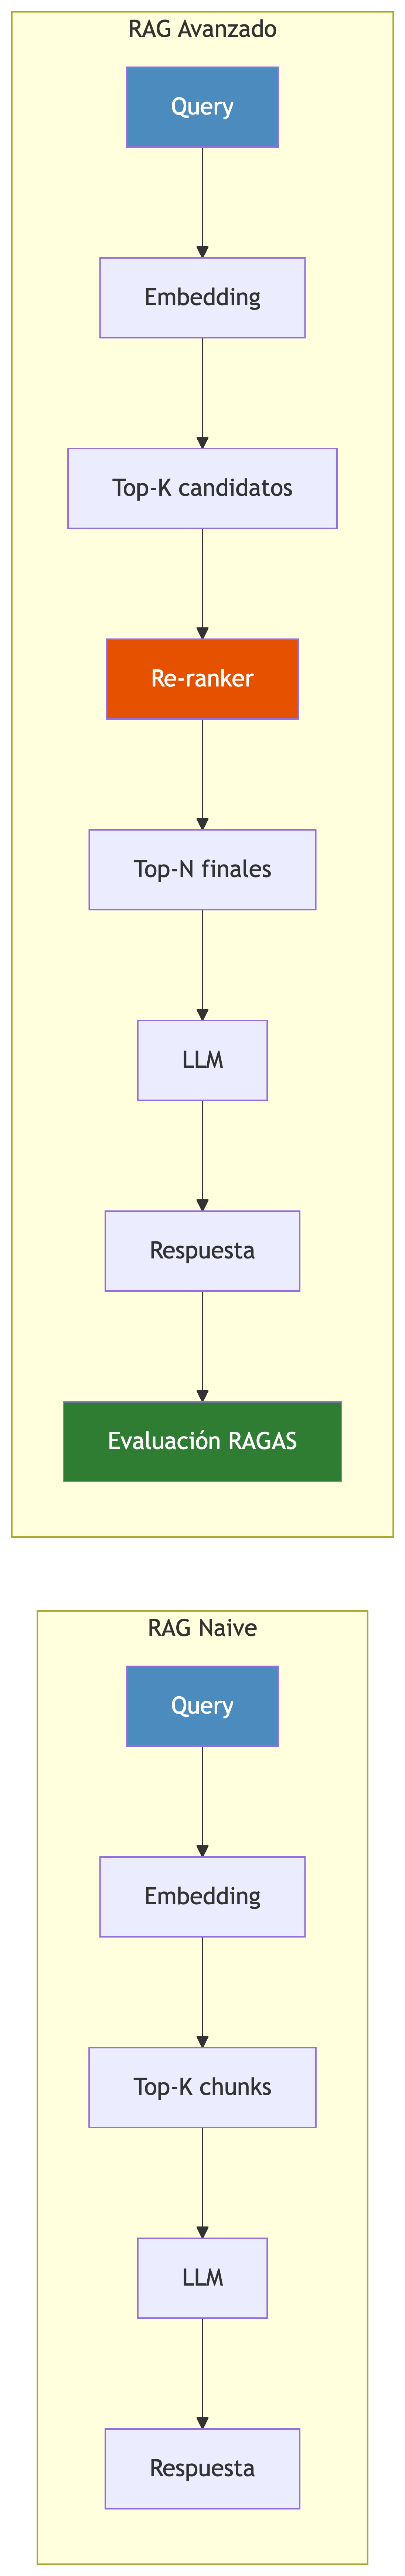

| Problema del RAG naive | Solución avanzada |
|------------------------------------|------------------------------------|
| Chunks irrelevantes en el top-K | **Re-ranking** con cross-encoder |
| Búsqueda en una sola fuente | **Retrievers combinados** (PDF + SQL + API) |
| Query mal formulada | **Query expansion** (HyDE, RAG-Fusion) |
| No sabemos si funciona bien | **Evaluación con RAGAS** (faithfulness, relevancy, precision) |
| Datos numéricos en tablas | **Text-to-SQL** o **RAG sobre DataFrames** |

------------------------------------------------------------------------

### Retrievers combinados y RAG multi-fuente

Imagina que trabajas en una empresa y tu jefe pregunta: *“¿Qué productos
del informe Q2 tienen margen inferior al 20%?”* La respuesta está en
**dos sitios distintos**: el informe trimestral (PDF, texto narrativo) y
la tabla de productos (SQL, datos numéricos). Un RAG multi-fuente busca
en ambos y combina los resultados.

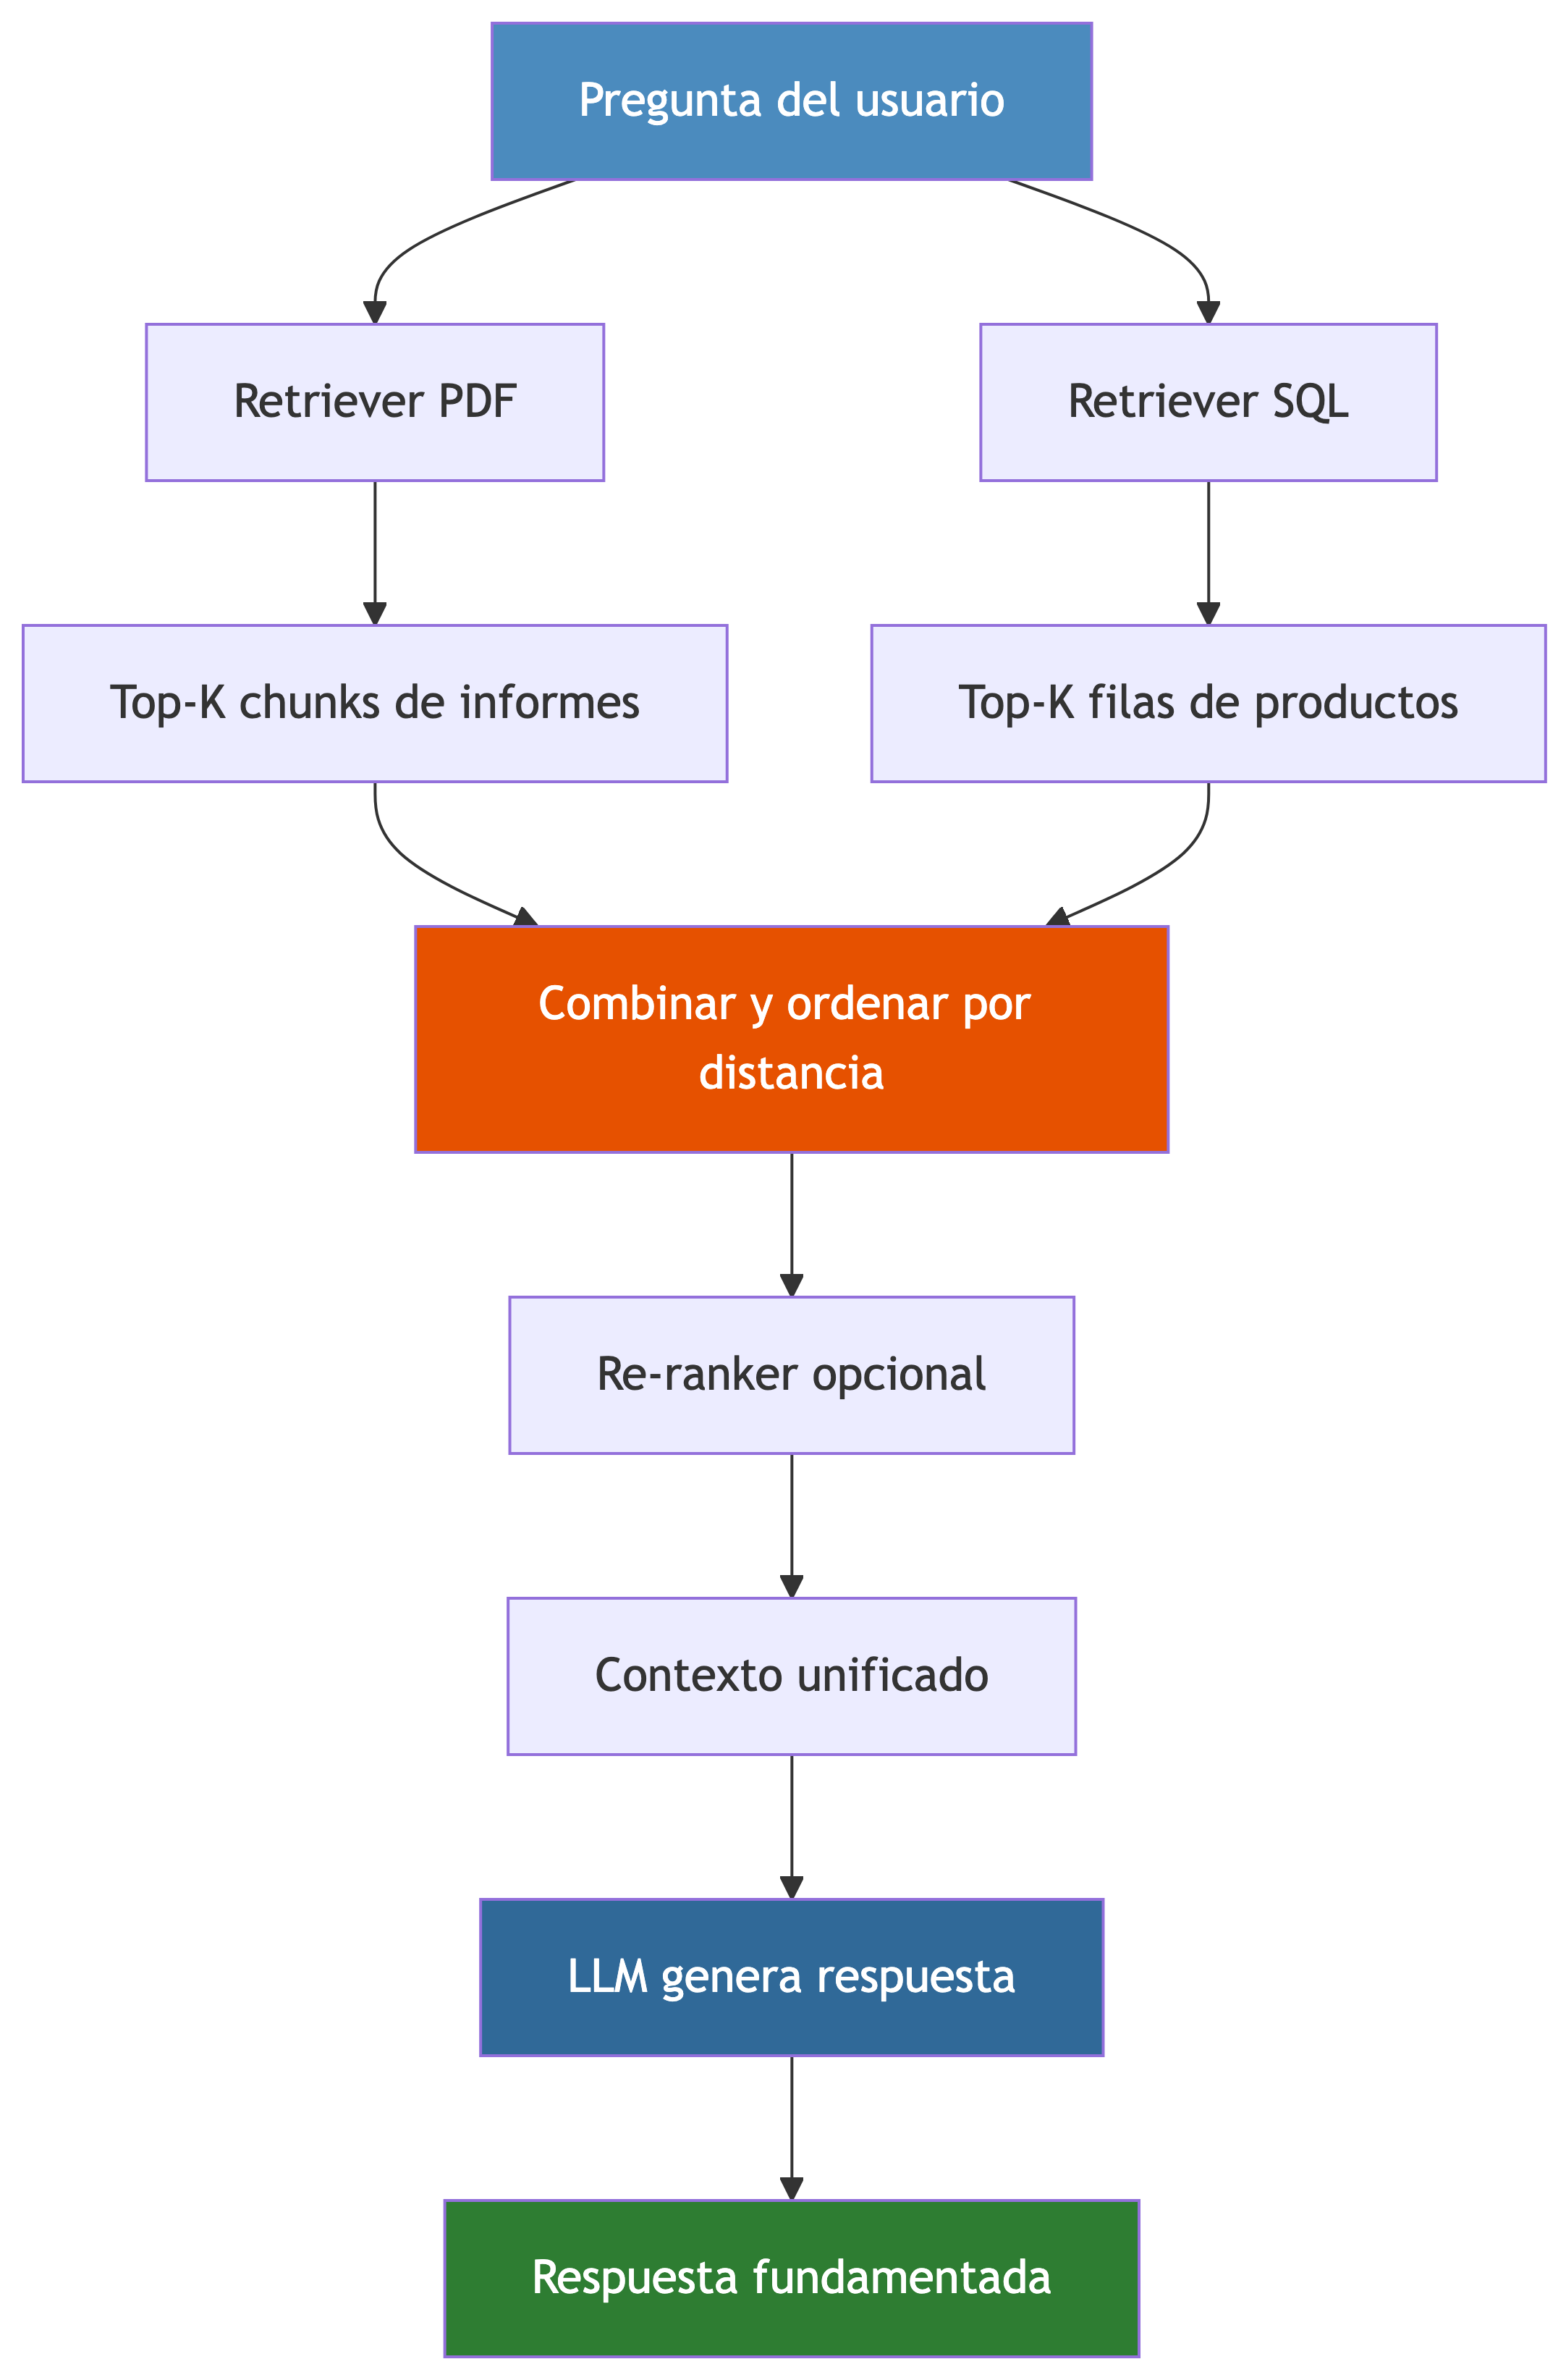

El patrón es siempre el mismo: cada fuente se convierte en “documentos
buscables” y se indexa en una colección separada.

| Fuente | Cómo convertirla a documento | Ejemplo |
|------------------------|------------------------|------------------------|
| **PDF / TXT** | Chunking con `RecursiveCharacterTextSplitter` | Informes, contratos, artículos |
| **Tabla SQL** | Cada fila → texto concatenado | `"Producto: X. Precio: Y€. Margen: Z%."` |
| **API REST** | Cada respuesta JSON → texto estructurado | Datos de CRM, ERP, servicios externos |
| **DataFrame** | Igual que SQL: fila → texto | Datos de pandas, CSV cargados |

In [4]:
import pandas as pd

df = pd.DataFrame({
    "producto": ["Monitor 4K", "NovaBuds Pro", "Silla Ergonómica"],
    "categoria": ["Electrónica", "Electrónica", "Hogar"],
    "precio": [349.0, 89.0, 249.0],
    "margen_pct": [42, 35, 38],
    "stock": [120, 250, 32],
})

df["texto"] = df.apply(
    lambda r: f"Producto: {r['producto']}. Categoría: {r['categoria']}. "
              f"Precio: {r['precio']}€. Margen: {r['margen_pct']}%. Stock: {r['stock']} unidades.",
    axis=1
)

print("Filas convertidas a documentos buscables:")
for t in df["texto"]:
    print(f"  → {t}")

Filas convertidas a documentos buscables:
  → Producto: Monitor 4K. Categoría: Electrónica. Precio: 349.0€. Margen: 42%. Stock: 120 unidades.
  → Producto: NovaBuds Pro. Categoría: Electrónica. Precio: 89.0€. Margen: 35%. Stock: 250 unidades.
  → Producto: Silla Ergonómica. Categoría: Hogar. Precio: 249.0€. Margen: 38%. Stock: 32 unidades.

La búsqueda combinada busca en cada colección por separado y mergea los
resultados ordenados por distancia:

In [5]:
from sentence_transformers import SentenceTransformer
import chromadb

model = SentenceTransformer("all-MiniLM-L6-v2")
chroma_client = chromadb.EphemeralClient()

col_productos = chroma_client.create_collection("productos_demo")
for i, texto in enumerate(df["texto"]):
    emb = model.encode(texto).tolist()
    col_productos.add(ids=[f"prod_{i}"], embeddings=[emb], documents=[texto])

col_informes = chroma_client.create_collection("informes_demo")
informes = [
    "El Monitor 4K lideró las ventas del Q1 con un margen del 42%. La demanda sigue alta.",
    "NovaBuds Pro tuvo un crecimiento del 18% en Q2. Es el producto más vendido de Electrónica.",
    "La Silla Ergonómica agotó stock en Q3. Se recomienda reposición urgente antes de fin de año.",
]
for i, texto in enumerate(informes):
    emb = model.encode(texto).tolist()
    col_informes.add(ids=[f"inf_{i}"], embeddings=[emb], documents=[texto])

print(f"✅ Colecciones: productos ({col_productos.count()}), informes ({col_informes.count()})")

✅ Colecciones: productos (3), informes (3)

In [6]:
def buscar_combinada(query, k_por_fuente=2):
    query_emb = model.encode(query).tolist()

    res_prod = col_productos.query(query_embeddings=[query_emb], n_results=k_por_fuente)
    res_inf = col_informes.query(query_embeddings=[query_emb], n_results=k_por_fuente)

    resultados = []
    for i in range(len(res_prod["ids"][0])):
        resultados.append({
            "fuente": "productos",
            "texto": res_prod["documents"][0][i],
            "distancia": res_prod["distances"][0][i],
        })
    for i in range(len(res_inf["ids"][0])):
        resultados.append({
            "fuente": "informes",
            "texto": res_inf["documents"][0][i],
            "distancia": res_inf["distances"][0][i],
        })

    resultados.sort(key=lambda x: x["distancia"])
    return resultados

resultados = buscar_combinada("¿Qué productos tienen problemas de stock?")
print("Resultados combinados (ordenados por distancia):")
for r in resultados:
    print(f"  [{r['distancia']:.4f}] ({r['fuente']}) {r['texto'][:80]}...")

Resultados combinados (ordenados por distancia):
  [0.8910] (productos) Producto: Silla Ergonómica. Categoría: Hogar. Precio: 249.0€. Margen: 38%. Stock...
  [0.9185] (productos) Producto: NovaBuds Pro. Categoría: Electrónica. Precio: 89.0€. Margen: 35%. Stoc...
  [0.9278] (informes) NovaBuds Pro tuvo un crecimiento del 18% en Q2. Es el producto más vendido de El...
  [0.9514] (informes) La Silla Ergonómica agotó stock en Q3. Se recomienda reposición urgente antes de...

> **Regla práctica**
>
> Empieza con **una sola fuente**. Añade la segunda solo si las
> preguntas de tus usuarios realmente requieren cruzar datos de
> distintos orígenes. Cada fuente adicional añade complejidad al
> pipeline y puntos de fallo.

------------------------------------------------------------------------

### Bi-encoder vs Cross-encoder

Los modelos de embeddings que has usado hasta ahora (`e5-small-v2`,
`all-MiniLM-L6-v2`) son **bi-encoders**: codifican cada texto por
separado y comparan los vectores resultantes. Son rápidos porque los
embeddings se pueden precomputar y almacenar.

Un **cross-encoder** funciona de forma distinta: recibe los dos textos
juntos y produce un único score de relevancia. Es más preciso pero mucho
más lento, porque no se puede precomputar.

**Un bi-encoder es como comparar dos fotos de lejos: rápido pero
impreciso. Un cross-encoder es como compararlas con lupa: lento pero
preciso.**

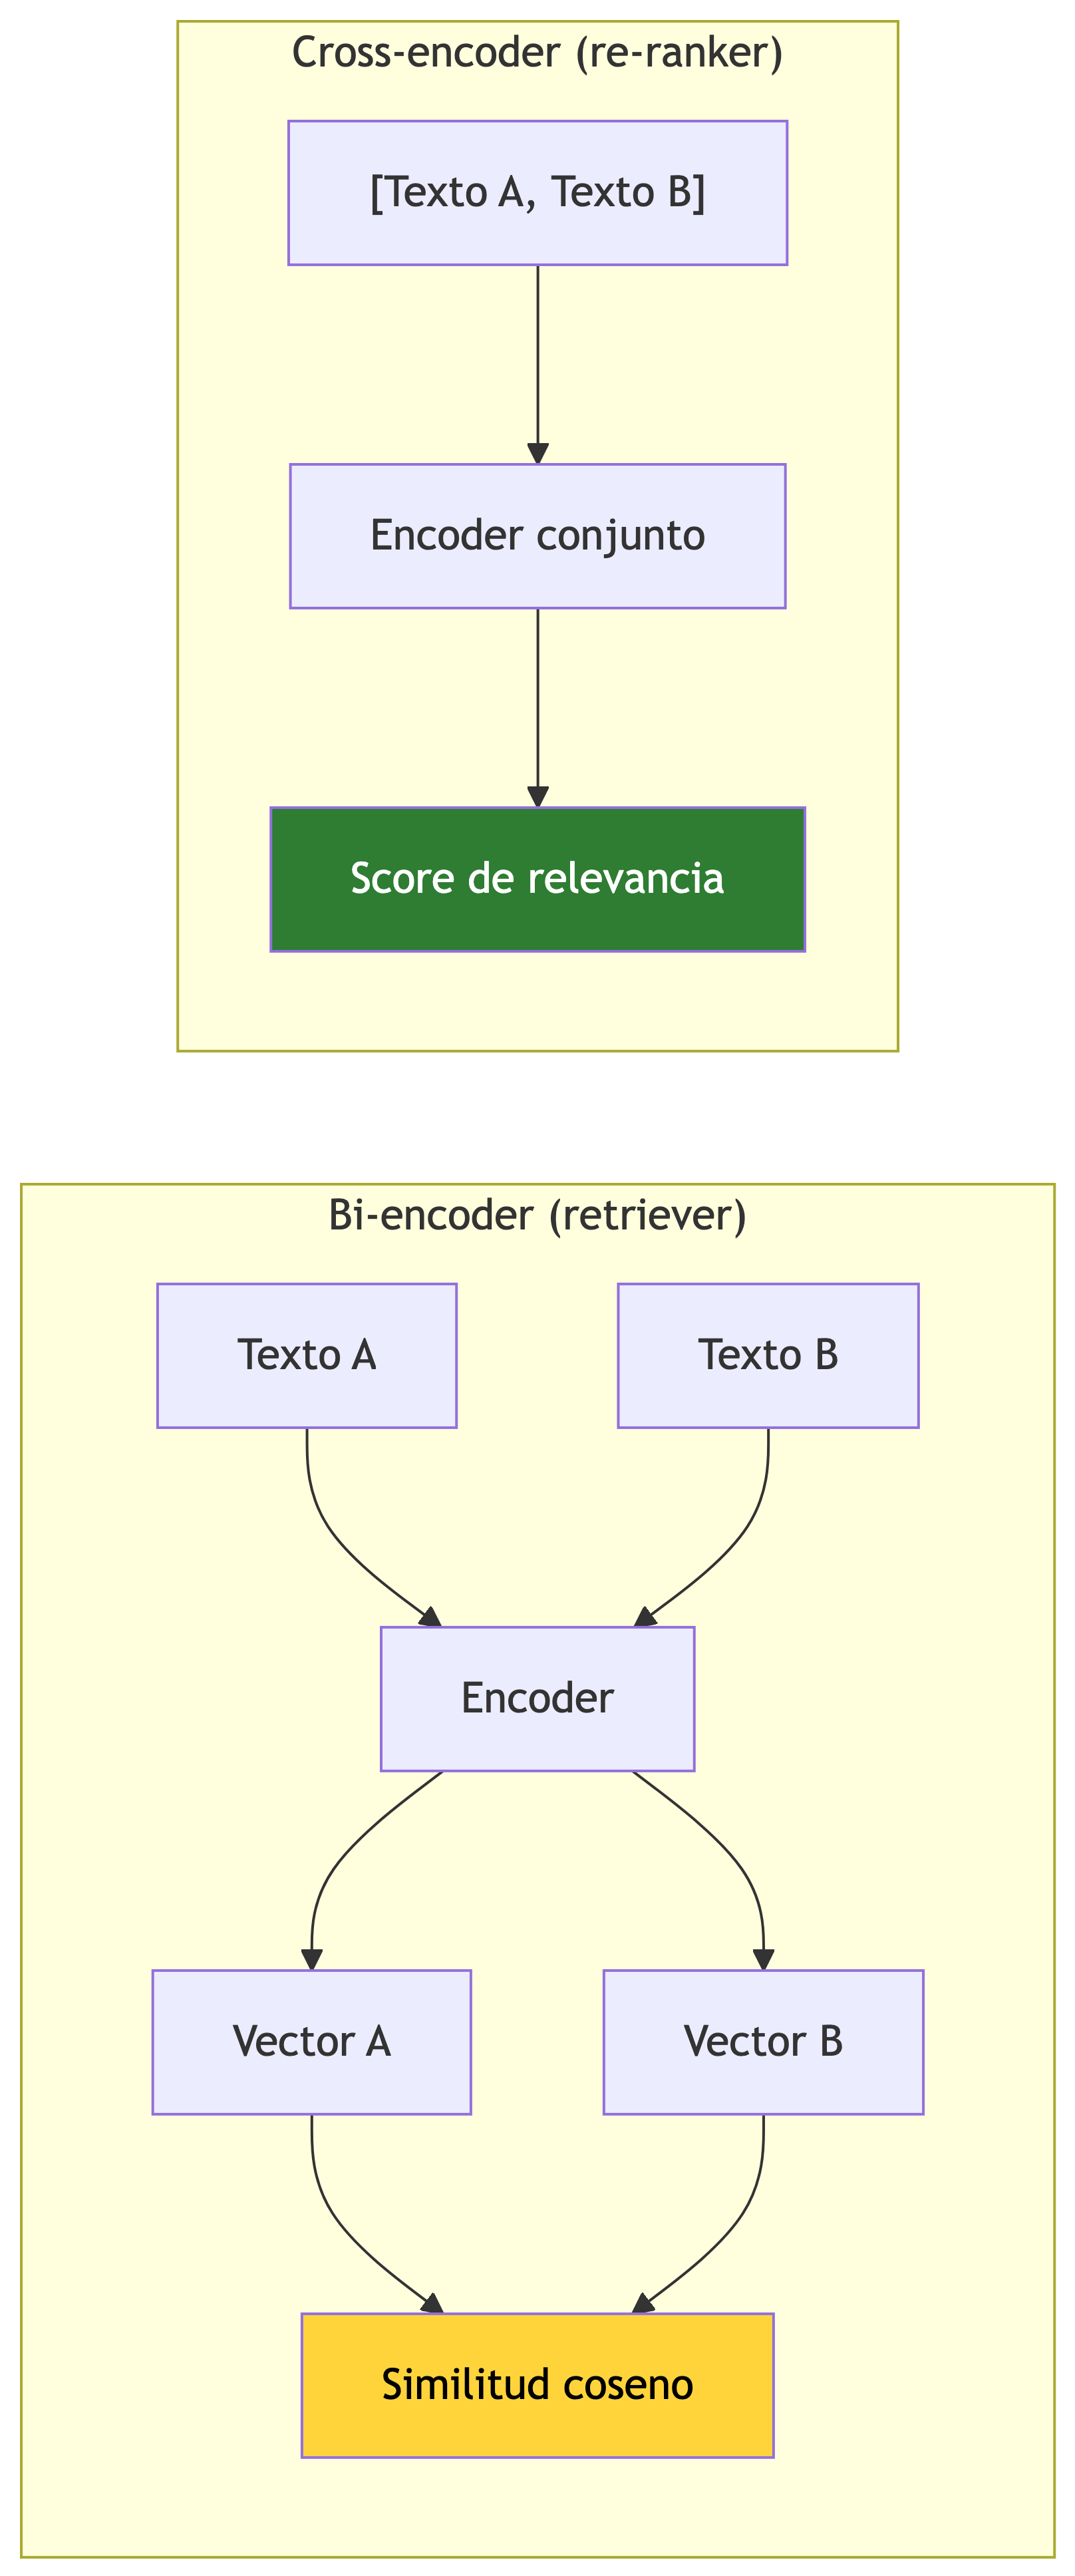

|  | Bi-encoder | Cross-encoder |
|------------------------|------------------------|------------------------|
| **Entrada** | Cada texto por separado | Ambos textos juntos |
| **Velocidad** | Rápido (ms, precomputable) | Lento (100ms+ por par) |
| **Precisión** | Buena | Excelente |
| **Precomputable** | Sí (embeddings en Vector DB) | No (recalcula cada vez) |
| **Uso en RAG** | Retriever (1ª fase) | Re-ranker (2ª fase) |
| **Ejemplo** | `e5-small-v2`, `all-MiniLM-L6-v2` | `ms-marco-MiniLM`, FlashRank |

> **¿Por qué no usar solo cross-encoder?**
>
> Porque es **O(n)** en latencia: para comparar tu query con 10.000
> chunks necesitarías 10.000 pasadas por el cross-encoder. El bi-encoder
> hace esa misma comparación en milisegundos gracias a los embeddings
> precomputados. La solución es usar ambos en dos fases.

------------------------------------------------------------------------

### Re-ranking: la segunda pasada

El re-ranking es la técnica más impactante y sencilla de implementar.
Funciona en dos fases:

1.  **Fase 1 — Retriever (bi-encoder):** busca los top-20 candidatos más
    similares por embedding. Rápido, cubre todo el corpus.
2.  **Fase 2 — Re-ranker (cross-encoder):** relee esos 20 candidatos
    junto a la query y los reordena por relevancia real. Devuelve los
    top-3 finales.

**El retriever es como un buscador que te da 20 resultados de Google. El
re-ranker es como tú releyendo los 20 y reordenándolos por relevancia
real.**

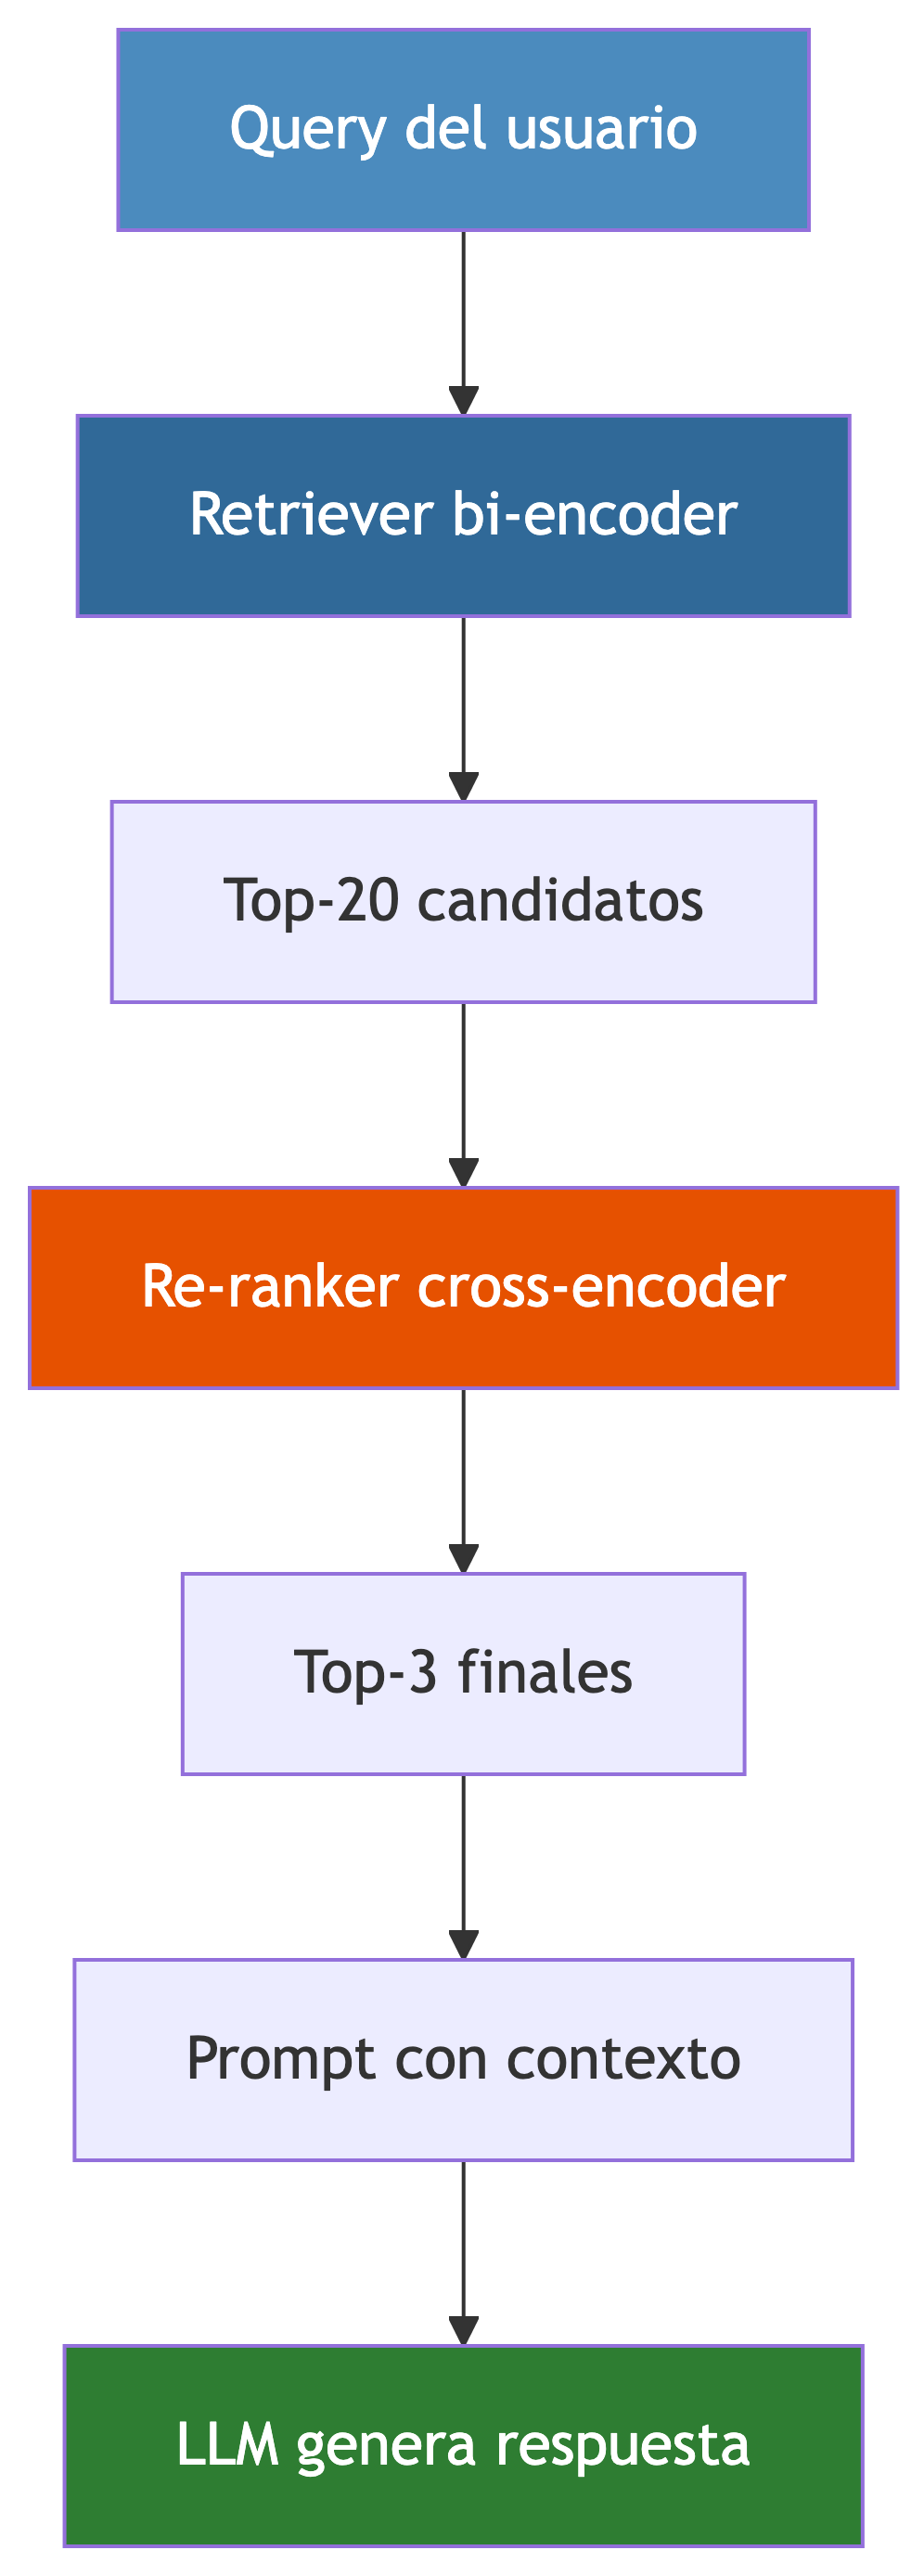

| Modelo de re-ranking       | Tamaño | Velocidad      | Calidad   |
|----------------------------|--------|----------------|-----------|
| `ms-marco-MiniLM-L-6-v2`   | ~30 MB | Rápido         | Buena     |
| `ms-marco-TinyBERT-L-2-v2` | ~15 MB | Muy rápido     | Aceptable |
| Cohere Rerank              | API    | Depende de red | Excelente |
| FlashRank                  | ~5 MB  | Muy rápido     | Buena     |

In [7]:
from langchain_community.document_compressors import FlashrankRerank
from langchain_core.documents import Document

reranker = FlashrankRerank(top_n=3, model="ms-marco-TinyBERT-L-2-v2")

docs = [Document(page_content=r["texto"], metadata={"fuente": r["fuente"]}) for r in resultados]

query_test = "¿Qué productos de electrónica tienen mejor margen?"
reranked = reranker.compress_documents(docs, query_test)

print("ANTES del re-ranker (orden por embedding):")
for r in resultados[:3]:
    print(f"  [{r['distancia']:.4f}] {r['texto'][:80]}...")

print("\nDESPUÉS del re-ranker (orden por cross-encoder):")
for doc in reranked:
    print(f"  {doc.page_content[:80]}...")

ANTES del re-ranker (orden por embedding):
  [0.8910] Producto: Silla Ergonómica. Categoría: Hogar. Precio: 249.0€. Margen: 38%. Stock...
  [0.9185] Producto: NovaBuds Pro. Categoría: Electrónica. Precio: 89.0€. Margen: 35%. Stoc...
  [0.9278] NovaBuds Pro tuvo un crecimiento del 18% en Q2. Es el producto más vendido de El...

DESPUÉS del re-ranker (orden por cross-encoder):
  Producto: NovaBuds Pro. Categoría: Electrónica. Precio: 89.0€. Margen: 35%. Stoc...
  Producto: Silla Ergonómica. Categoría: Hogar. Precio: 249.0€. Margen: 38%. Stock...
  NovaBuds Pro tuvo un crecimiento del 18% en Q2. Es el producto más vendido de El...

> **Mide siempre el impacto**
>
> El re-ranker añade latencia (100-500ms extra) y complejidad. Antes de
> añadirlo a producción, compara las métricas RAGAS con y sin re-ranker
> sobre tu dataset de evaluación. Si la mejora es marginal (\<5% en
> faithfulness), puede que no merezca la pena el coste extra.

> **Regla práctica**
>
> **Retriever top-20 + re-ranker top-3** es un buen punto de partida. Si
> tu corpus es pequeño (\<1000 chunks), un retriever top-5 sin re-ranker
> puede bastar.

------------------------------------------------------------------------

### Query expansion: HyDE y RAG-Fusion

A veces el problema no está en el retriever sino en la **query**. Una
pregunta mal formulada produce embeddings que no coinciden con los
documentos relevantes. Las técnicas de query expansion reformulan la
pregunta para mejorar la recuperación.

#### HyDE (Hypothetical Document Embeddings)

En vez de buscar con tu pregunta tal cual, primero pides al LLM que
**genere una respuesta hipotética** y buscas con el embedding de esa
respuesta imaginaria.

**Es como buscar un restaurante no por su nombre sino describiendo la
comida que quieres comer.**

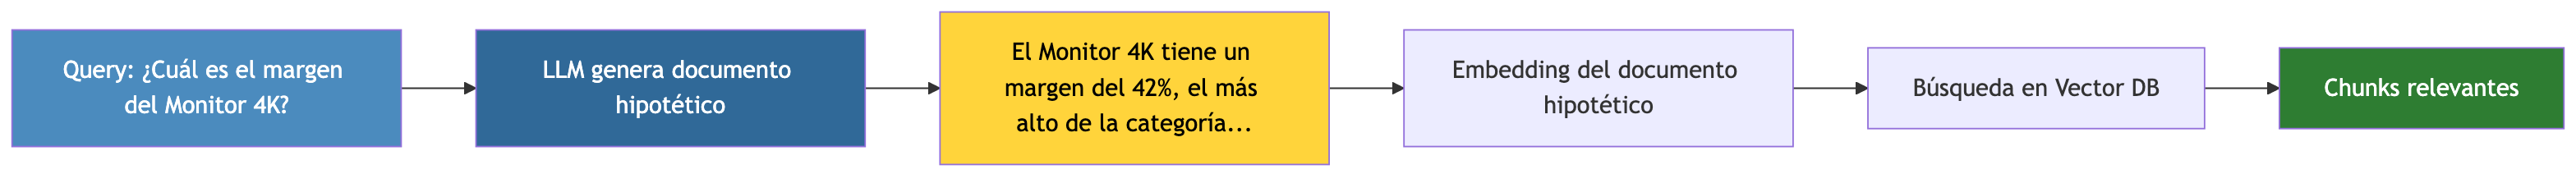

In [8]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver HyDE en acción.")
else:
    query_original = "¿Cuál es el margen del Monitor 4K?"

    respuesta_hipotetica = client.chat.completions.create(
        model="gemma4:e2b-mlx",
        messages=[{"role": "user", "content": f"Responde brevemente a esta pregunta como si fueras un informe de ventas:\n{query_original}"}],
        temperature=0.7,
    ).choices[0].message.content

    print(f"Query original: {query_original}")
    print(f"\nDocumento hipotético generado por el LLM:")
    print(f"  {respuesta_hipotetica}")

    emb_original = model.encode(query_original).tolist()
    emb_hyde = model.encode(respuesta_hipotetica).tolist()

    res_original = col_productos.query(query_embeddings=[emb_original], n_results=2)
    res_hyde = col_productos.query(query_embeddings=[emb_hyde], n_results=2)

    print(f"\nBúsqueda con query original:")
    for doc in res_original["documents"][0]:
        print(f"  {doc[:80]}...")

    print(f"\nBúsqueda con HyDE (embedding del documento hipotético):")
    for doc in res_hyde["documents"][0]:
        print(f"  {doc[:80]}...")

INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"

Query original: ¿Cuál es el margen del Monitor 4K?

Documento hipotético generado por el LLM:
  El margen de beneficio requiere la revisión de los costos internos del producto. Por favor, proporcione los datos financieros relevantes para un cálculo preciso.


Búsqueda con query original:
  Producto: Monitor 4K. Categoría: Electrónica. Precio: 349.0€. Margen: 42%. Stock...
  Producto: Silla Ergonómica. Categoría: Hogar. Precio: 249.0€. Margen: 38%. Stock...

Búsqueda con HyDE (embedding del documento hipotético):
  Producto: NovaBuds Pro. Categoría: Electrónica. Precio: 89.0€. Margen: 35%. Stoc...
  Producto: Monitor 4K. Categoría: Electrónica. Precio: 349.0€. Margen: 42%. Stock...

#### RAG-Fusion

En vez de buscar una vez, **reformulas la pregunta de 5 formas
distintas**, buscas con cada una, y combinas los resultados con
**Reciprocal Rank Fusion (RRF)**: los documentos que aparecen en varias
búsquedas suben en el ranking.

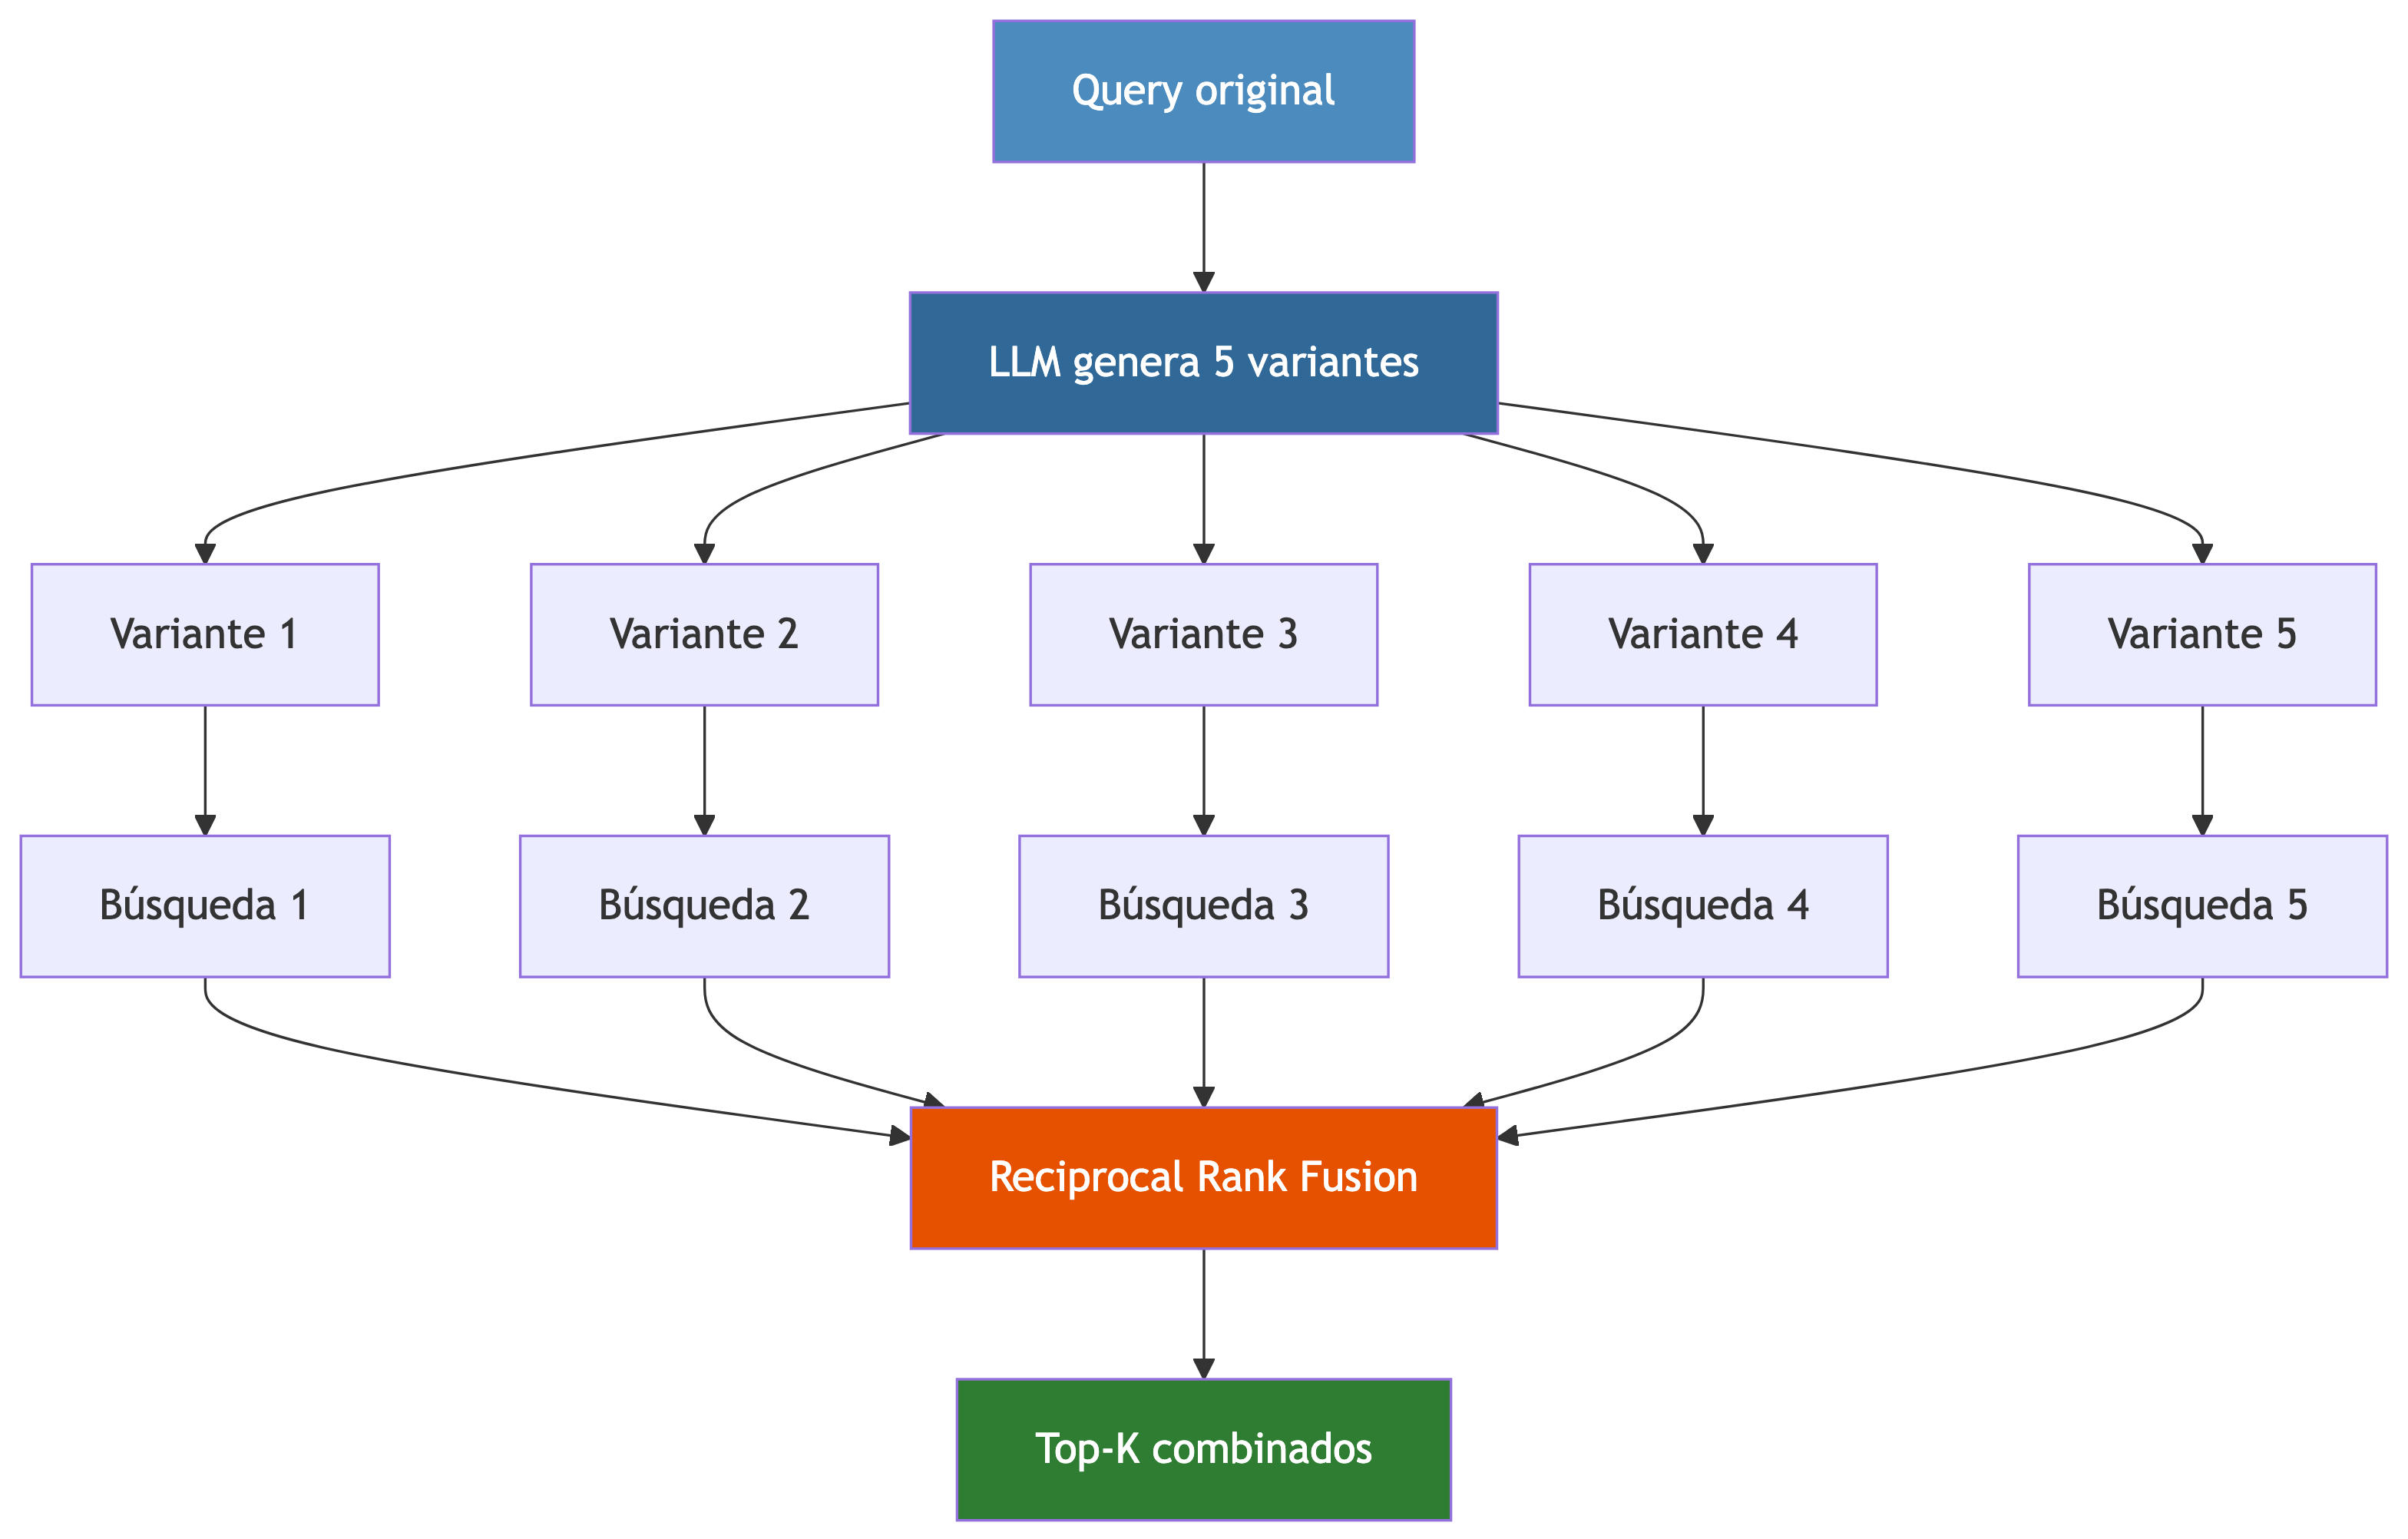

| Técnica | Coste (llamadas LLM) | Mejora esperada | Cuándo usarla |
|------------------|------------------|------------------|------------------|
| **Query simple** | 0 | — | Baseline, preguntas bien formuladas |
| **HyDE** | 1 llamada | 5-15% en recall | Preguntas cortas o ambiguas |
| **RAG-Fusion** | 1 llamada + 5 búsquedas | 10-20% en recall | Preguntas complejas, multi-aspecto |

> **Cuándo usar query expansion**
>
> - **HyDE:** cuando la pregunta es corta o usa vocabulario distinto al
>   de los documentos. El documento hipotético “traduce” la query al
>   lenguaje del corpus.
> - **RAG-Fusion:** cuando la pregunta tiene múltiples aspectos (ej.
>   “compara la evolución de ventas y márgenes”). Las variantes cubren
>   cada aspecto por separado.
> - **Ninguna:** cuando la pregunta ya es clara y específica. Añadir
>   complejidad innecesaria puede empeorar los resultados.

------------------------------------------------------------------------

### Evaluación de RAG con RAGAS

Evaluar un RAG “a ojo” no basta. Necesitas métricas objetivas que te
digan **qué componente falla** cuando el sistema da una mala respuesta.

**Evaluar un RAG a ojo es como probar un coche dando una vuelta a la
manzana. RAGAS es como pasar la ITV: mide cosas concretas con criterios
objetivos.**

RAGAS evalúa 3 dimensiones independientes:

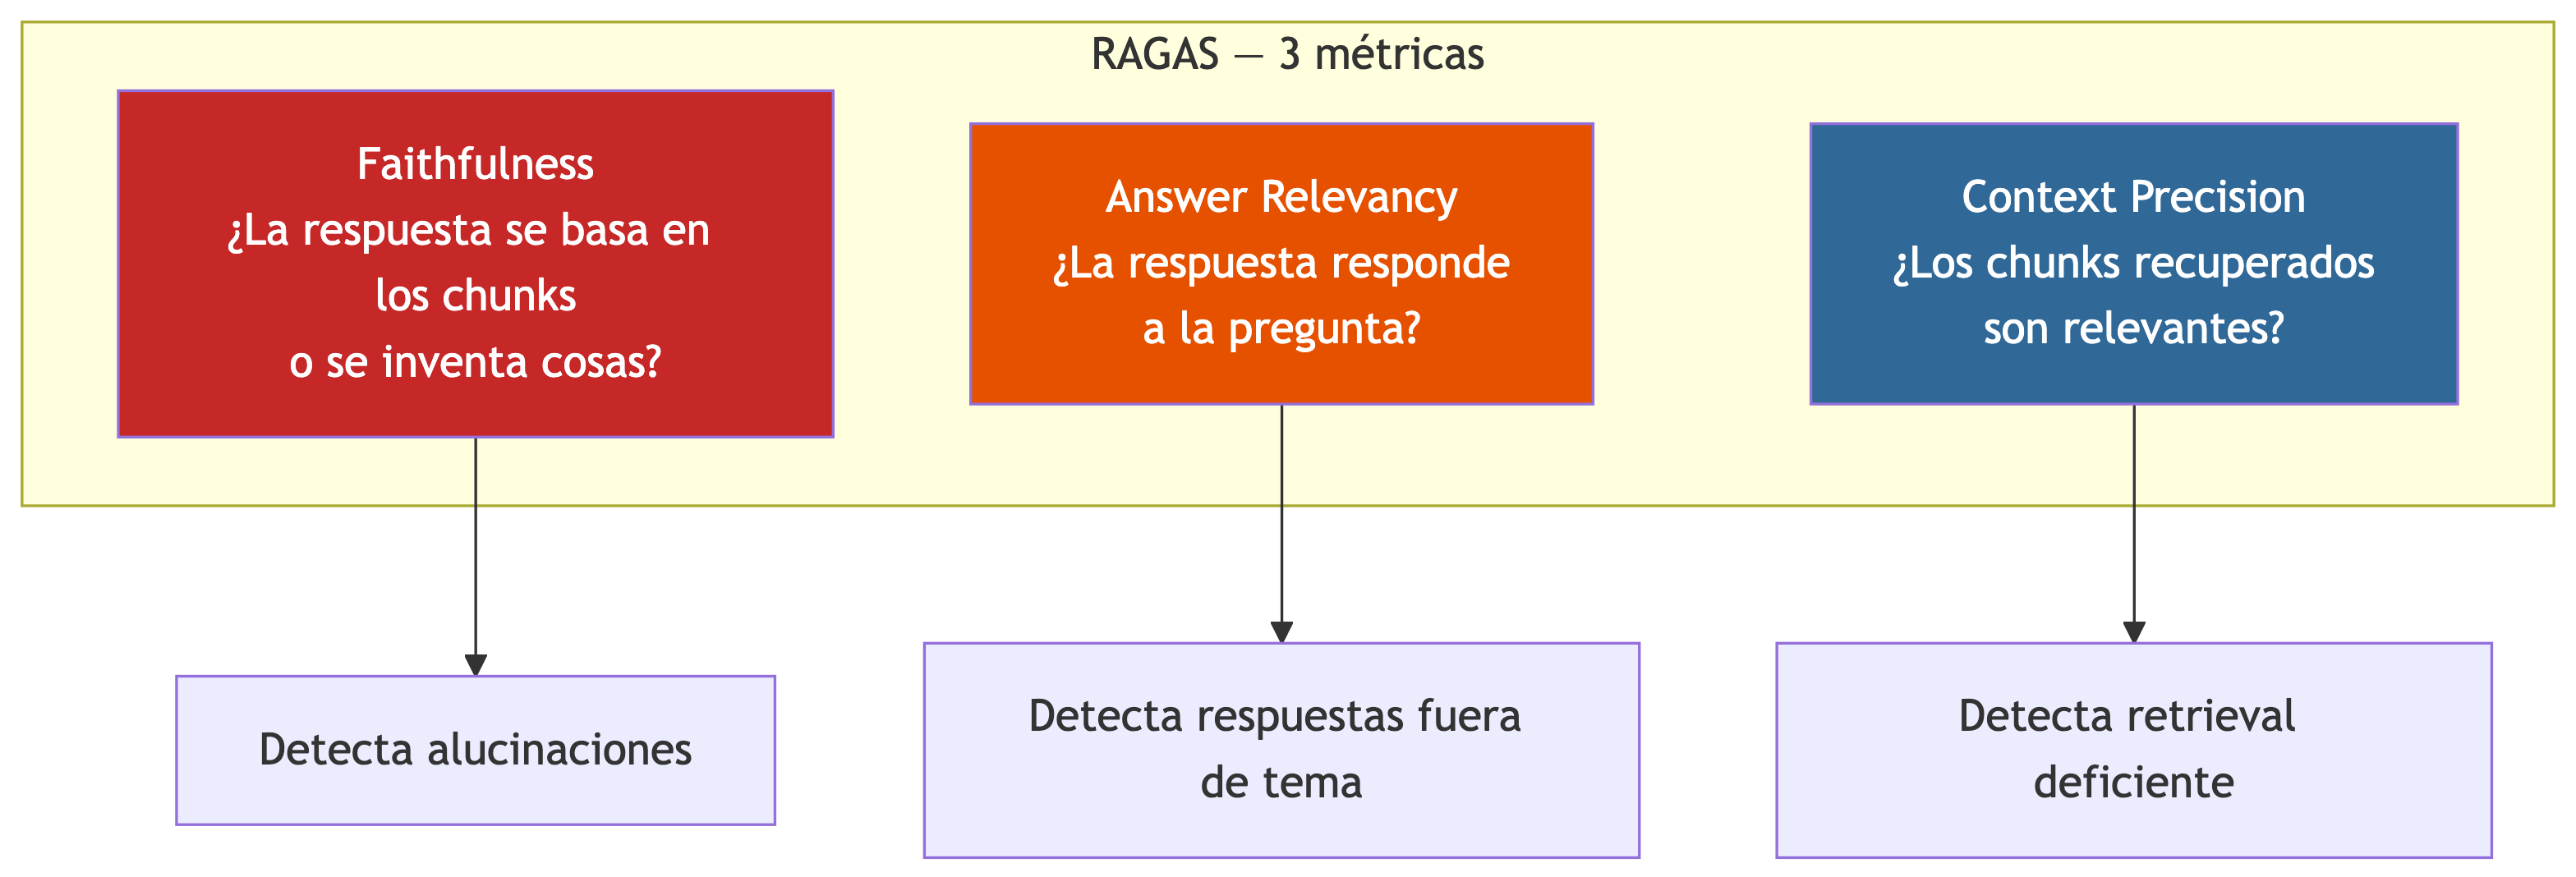

| Métrica | Qué mide | Rango | Cómo se calcula (intuitivo) |
|------------------|------------------|------------------|------------------|
| **Faithfulness** | Fidelidad al contexto | \[0, 1\] | Se extraen afirmaciones (claims) de la respuesta y se verifica cada una contra los chunks recuperados. Si todas están respaldadas → 1.0 |
| **Answer Relevancy** | Pertinencia de la respuesta | \[0, 1\] | Se generan preguntas inversas a partir de la respuesta y se mide su similitud con la pregunta original. Si coinciden → 1.0 |
| **Context Precision** | Calidad del retrieval | \[0, 1\] | Se evalúa si los chunks relevantes aparecen arriba en el ranking de resultados. Si los buenos están primero → 1.0 |

> **¿Cómo interpreta RAGAS cada métrica?**
>
> **Faithfulness** te dice si el LLM **alucina**: si la respuesta dice
> “el margen es del 42%” pero ningún chunk menciona ese dato,
> faithfulness baja.
>
> **Answer Relevancy** te dice si el LLM **se va por las ramas**: si
> preguntas por el margen y responde sobre el stock, relevancy baja.
>
> **Context Precision** te dice si el retriever **encuentra lo
> correcto**: si los chunks relevantes están en la posición 8 de 10,
> precision baja.

#### Ground truth: el criterio humano

El **ground truth** es la respuesta que tú consideras correcta para cada
pregunta. Es el criterio humano contra el que se mide el sistema.

| Pregunta | Ground truth (respuesta esperada) | Chunks relevantes |
|------------------------|------------------------|------------------------|
| ¿Cuál es el margen del Monitor 4K? | El margen del Monitor 4K es del 42% | Chunk del informe Q1 que menciona el 42% |
| ¿Qué productos tienen stock crítico? | Tienda de Campaña (0 uds), Lámpara LED (15 uds), Escritorio (18 uds) | Chunks del informe Q3 + fila de productos |

> **El ground truth es subjetivo**
>
> Dos personas pueden definir respuestas válidas distintas para la misma
> pregunta. Documenta siempre tus criterios: qué consideras “correcto”,
> qué nivel de detalle exiges, qué fuentes usas como referencia.

#### Evaluación con RAGAS — ejemplo

In [9]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from datasets import Dataset
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

dataset_eval = {
    "question": [
        "¿Cuál es el margen del Monitor 4K?",
        "¿Qué productos tienen problemas de stock?",
        "¿Qué dice el informe Q2 sobre el Teclado Mecánico RGB?",
    ],
    "answer": [
        "El Monitor 4K tiene un margen del 42%, el más alto de la categoría de Electrónica de consumo.",
        "La Tienda de Campaña Ultralight tiene 0 unidades de stock y la Lámpara LED Smart tiene 15 unidades.",
        "El Teclado Mecánico RGB alcanzó 4.200 unidades vendidas en sus primeras 8 semanas con un margen del 28%.",
    ],
    "contexts": [
        ["El Monitor 4K lideró las ventas del Q1 con un margen del 42%."],
        ["La Tienda de Campaña Ultralight agotó existencias en septiembre (stock actual: 0 unidades).",
         "Producto: Lámpara LED Smart. Stock: 15 unidades."],
        ["El Teclado Mecánico RGB como novedad del trimestre, alcanzando 4.200 unidades vendidas en sus primeras 8 semanas. El margen del 28% en este producto es inferior al del Monitor 4K."],
    ],
    "ground_truth": [
        "El margen del Monitor 4K es del 42%.",
        "La Tienda de Campaña Ultralight tiene 0 unidades y la Lámpara LED Smart tiene 15 unidades.",
        "El Teclado Mecánico RGB vendió 4.200 unidades en 8 semanas con un margen del 28%.",
    ],
}

dataset_hf = Dataset.from_dict(dataset_eval)

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ejecutar la evaluación RAGAS.")
else:
    ragas_llm = ChatOpenAI(
        model="gemma4:e2b-mlx",
        base_url=LLM_URL,
        api_key=LLM_KEY,
        temperature=0,
    )

    ragas_embeddings = OpenAIEmbeddings(
        model="qwen3-embedding:0.6b",
        base_url=LLM_URL,
        api_key=LLM_KEY,
        tiktoken_enabled=False,
        check_embedding_ctx_length=False,
    )

    results = evaluate(
        dataset_hf,
        metrics=[faithfulness, answer_relevancy, context_precision],
        llm=ragas_llm,
        embeddings=ragas_embeddings,
    )

    df_results = results.to_pandas()
    print(df_results[["faithfulness", "answer_relevancy", "context_precision"]].round(3))
    print(f"\nMedias:")
    print(f"  Faithfulness:       {df_results['faithfulness'].mean():.3f}")
    print(f"  Answer Relevancy:   {df_results['answer_relevancy'].mean():.3f}")
    print(f"  Context Precision:  {df_results['context_precision'].mean():.3f}")

INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://llamus.cs.us.es/api/

   faithfulness  answer_relevancy  context_precision
0           0.5             0.000                1.0
1           1.0             0.458                1.0
2           1.0             0.509                1.0

Medias:
  Faithfulness:       0.833
  Answer Relevancy:   0.322
  Context Precision:  1.000

> **Umbrales orientativos**
>
> | Métrica               | Prototipo | Producción |
> |-----------------------|-----------|------------|
> | **Faithfulness**      | \> 0.6    | \> 0.8     |
> | **Answer Relevancy**  | \> 0.7    | \> 0.85    |
> | **Context Precision** | \> 0.5    | \> 0.7     |
>
> Si faithfulness es bajo, el problema está en el **LLM** (alucina). Si
> context precision es bajo, el problema está en el **retriever** (no
> encuentra los chunks correctos). Esto te dice exactamente qué
> componente mejorar.

------------------------------------------------------------------------

### RAG sobre datos estructurados

Hasta ahora hemos buscado en texto libre (PDFs, informes). Pero muchos
datos corporativos están en **tablas SQL** o **DataFrames**. Tienes dos
caminos:

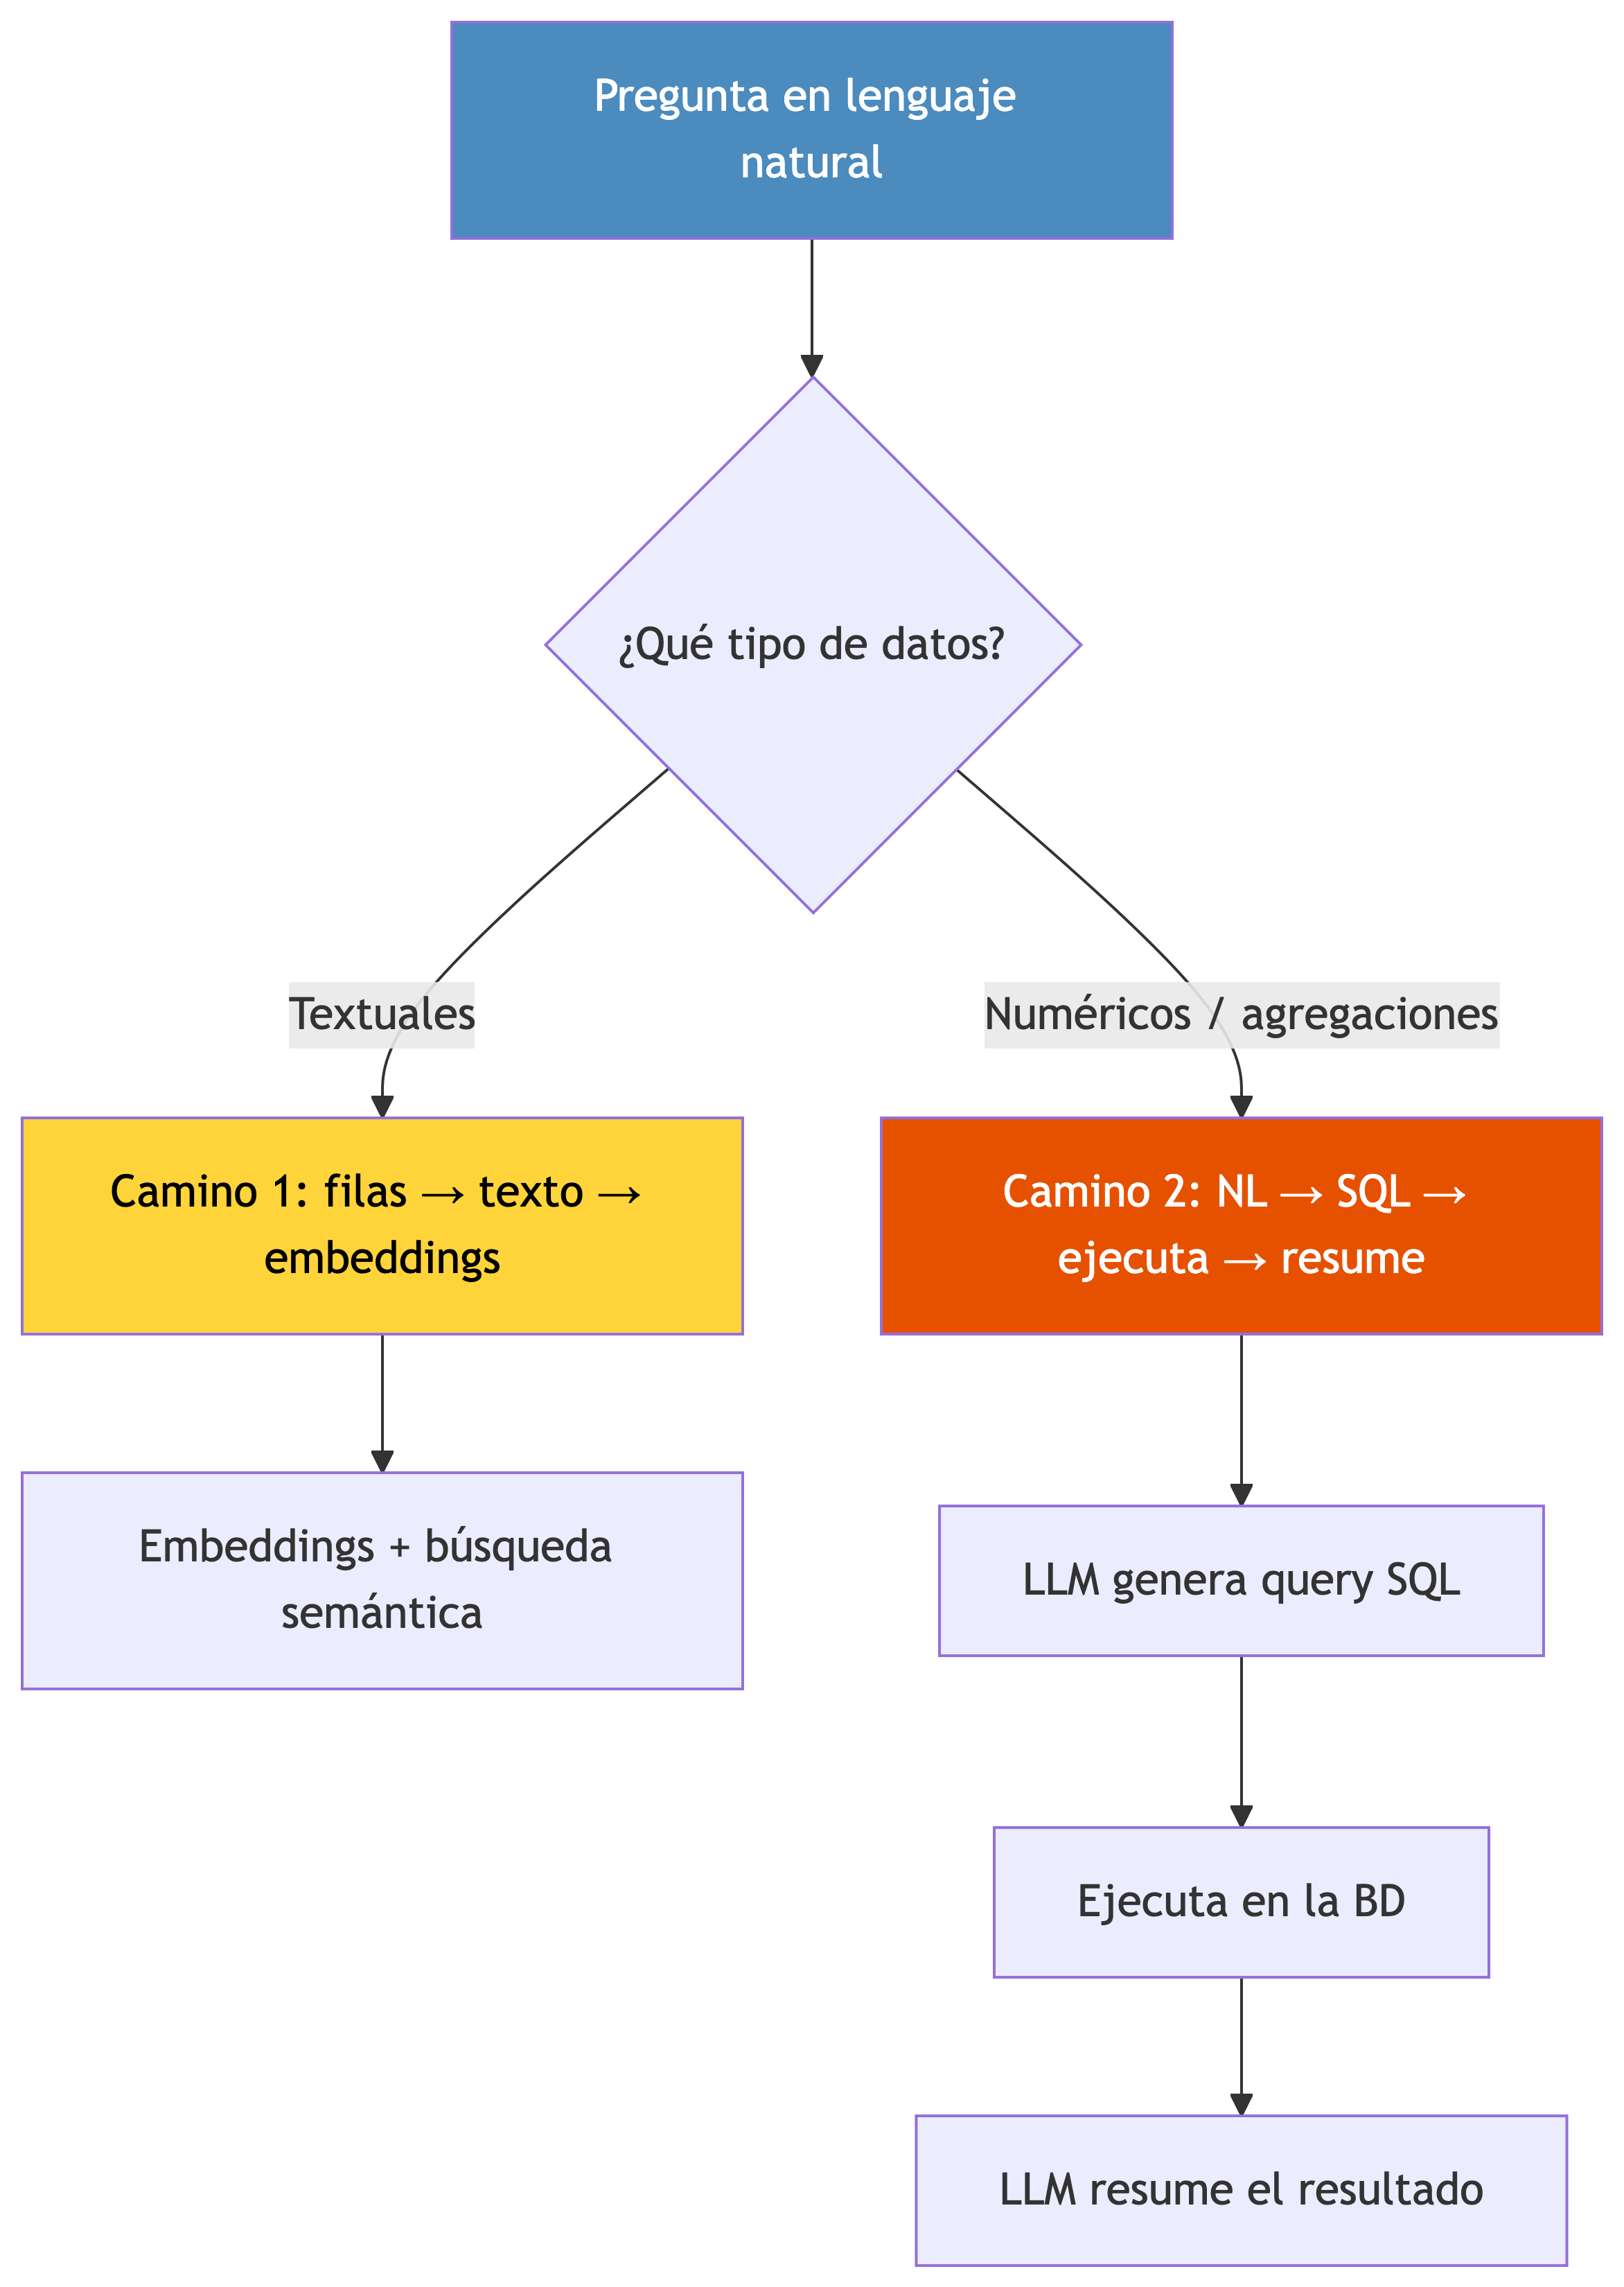

| Criterio | Camino 1: texto + embeddings | Camino 2: Text-to-SQL |
|------------------------|------------------------|------------------------|
| **Mejor para** | Búsqueda semántica (“productos similares a…”) | Consultas exactas (“ventas totales de Q2”) |
| **Datos numéricos** | No distingue 55000 de 52000 | Sabe que 55000 \> 52000 |
| **Agregaciones** | No puede hacer SUM, AVG, GROUP BY | Sí |
| **Riesgo** | Baja precisión en datos numéricos | SQL incorrecto o inyección |
| **Ya lo viste en** | [HPD 1](../evaluables/hpd1-embeddings.qmd) sección 1.6 | [02c-llamaindex.qmd](../bloque2/02c-llamaindex.qmd) sección SQL |

> **Text-to-SQL: potente pero peligroso**
>
> El LLM puede generar SQL incorrecto (columnas que no existen, JOINs
> mal formados) o incluso SQL malicioso si no sanitizas. Siempre:
>
> 1.  **Valida** que las columnas y tablas existen en el schema
> 2.  **Sanitiza** bloqueando DROP, DELETE, UPDATE, INSERT
> 3.  **Limita** el número de filas devueltas
> 4.  **Usa** una base de datos de solo lectura

En el [HPD 4](../evaluables/hpd4-rag-mixto.qmd) combinarás ambos
caminos: búsqueda semántica en PDFs de informes + datos estructurados de
una tabla de productos.

------------------------------------------------------------------------

### Resumen: mapa completo de técnicas RAG

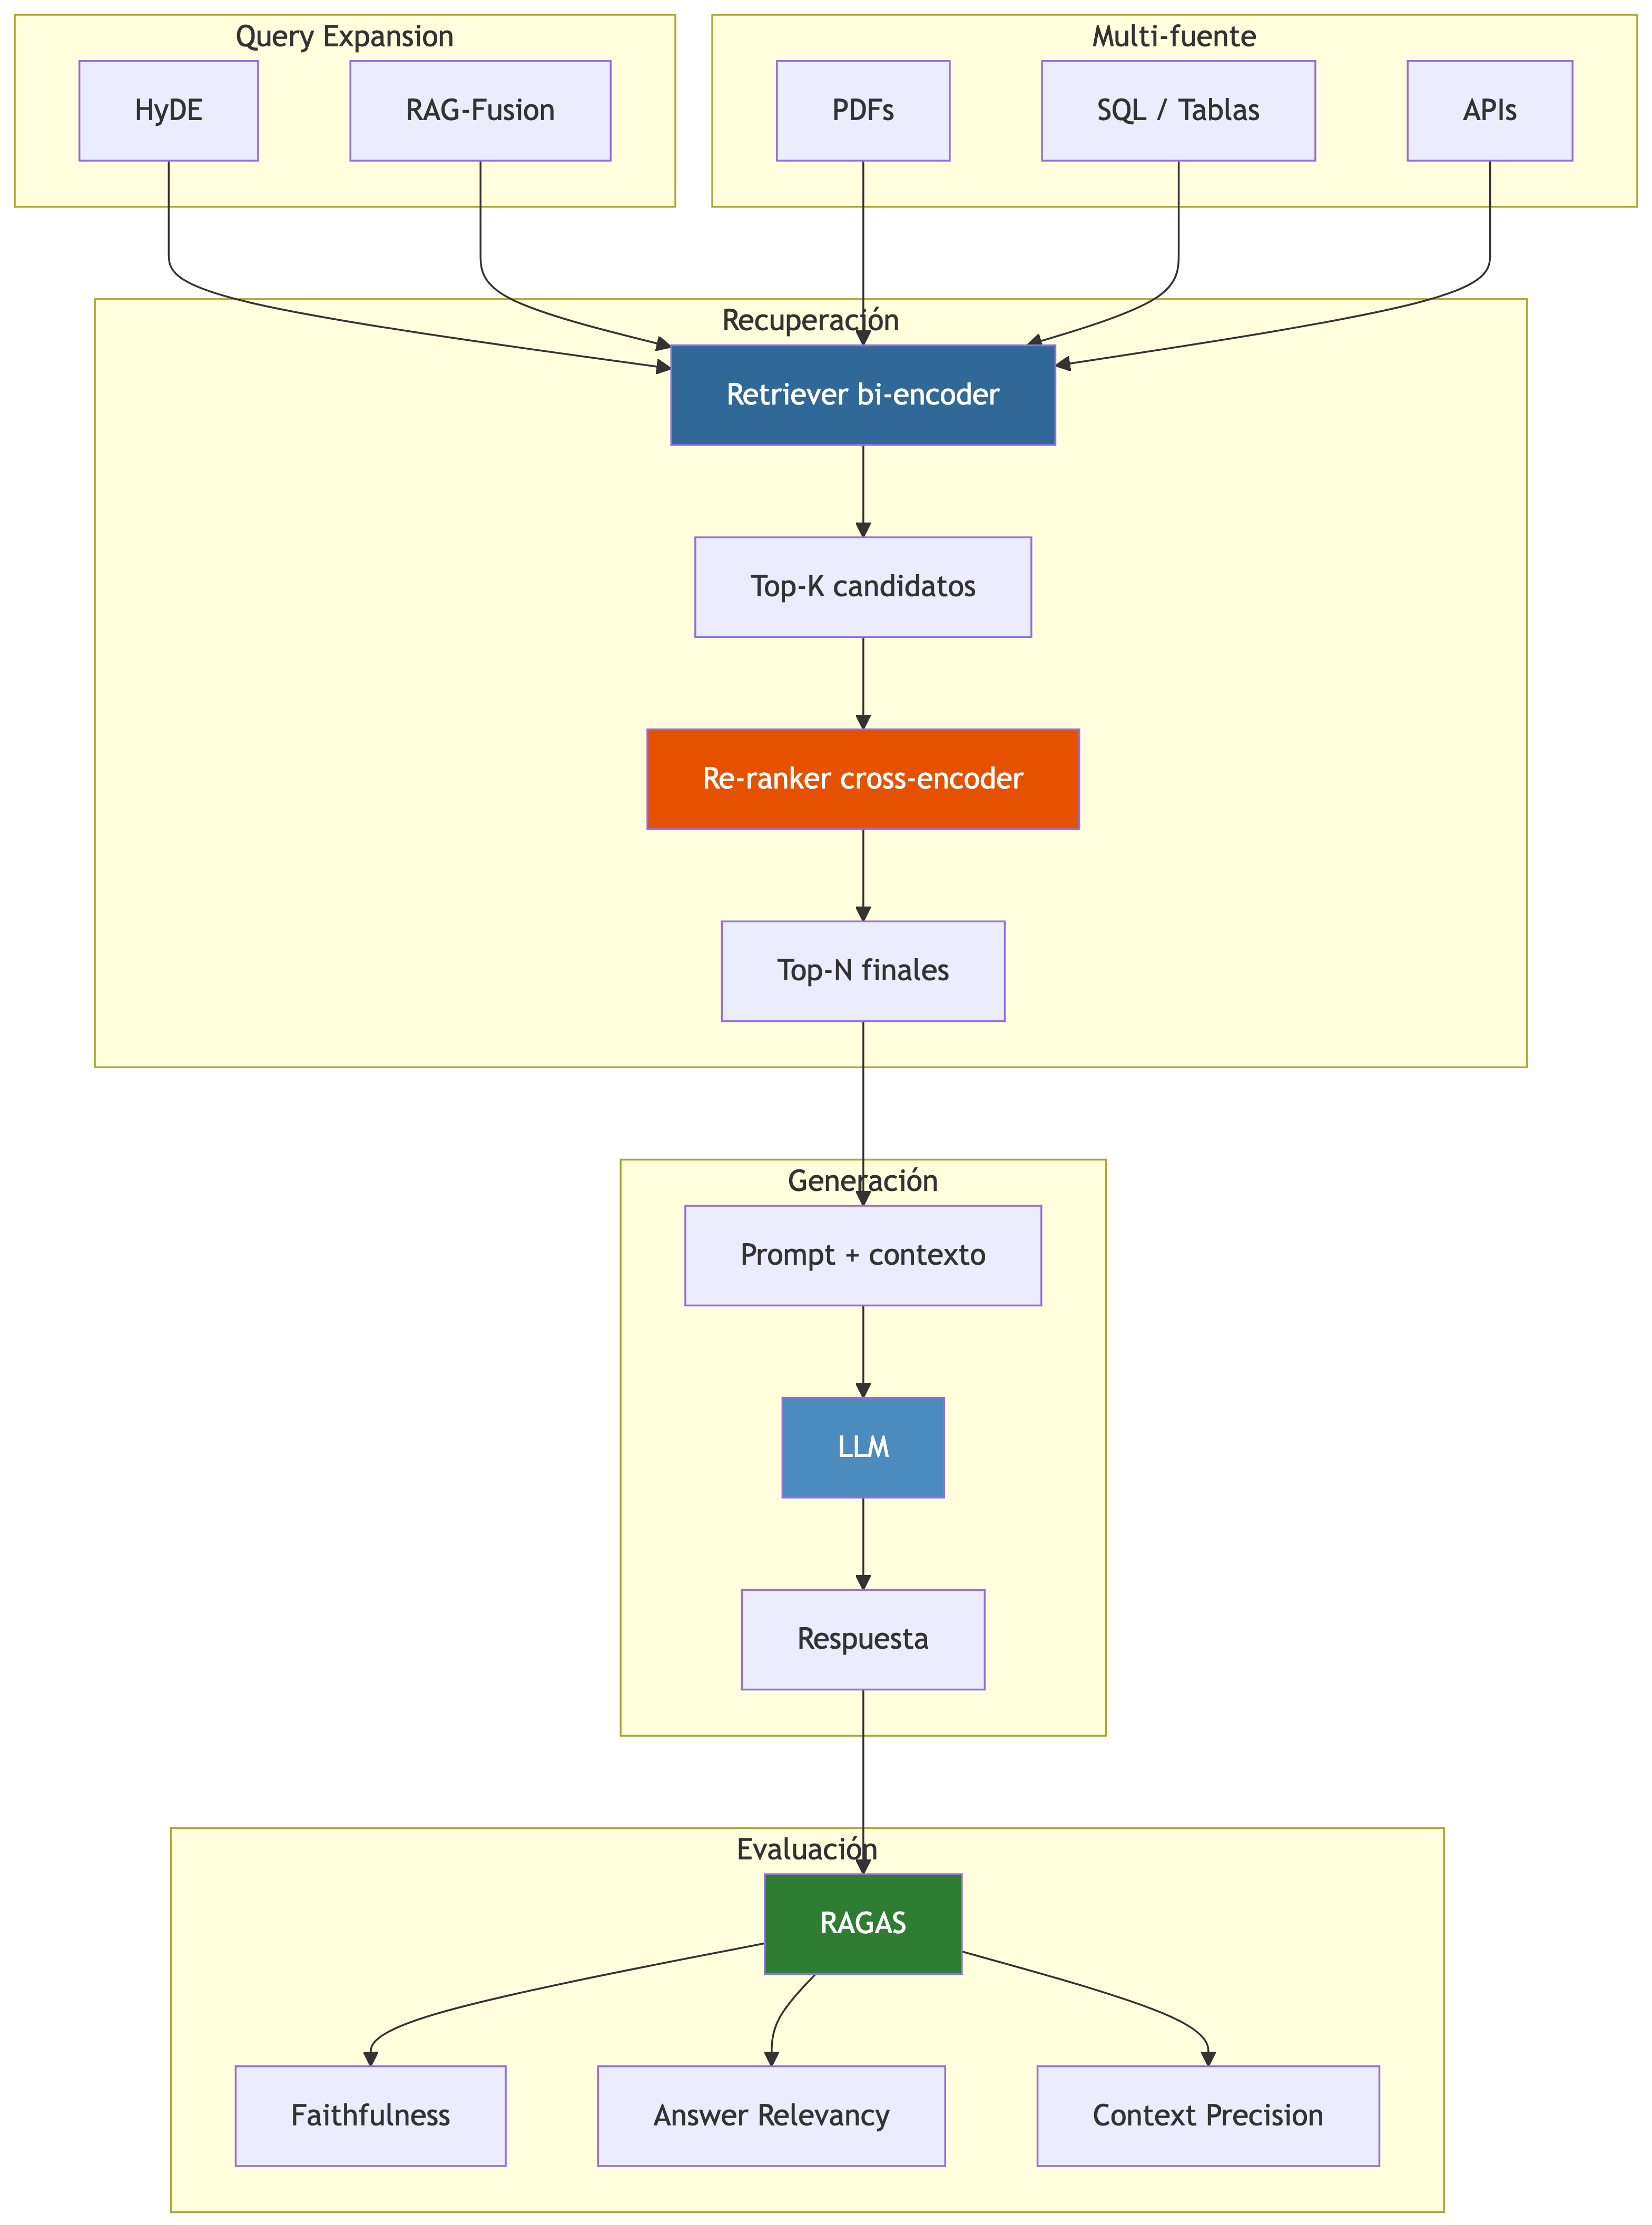

| Técnica | Problema que resuelve | Coste adicional | Mejora esperada |
|------------------|------------------|------------------|------------------|
| **Re-ranking** | Chunks irrelevantes en top-K | +100-500ms latencia | 5-15% en faithfulness |
| **HyDE** | Query mal formulada | 1 llamada LLM extra | 5-15% en recall |
| **RAG-Fusion** | Preguntas multi-aspecto | 5 búsquedas extra | 10-20% en recall |
| **Multi-fuente** | Datos en múltiples orígenes | Complejidad del pipeline | Cobertura de preguntas cruzadas |
| **Text-to-SQL** | Datos numéricos en tablas | Riesgo de SQL incorrecto | Precisión en consultas numéricas |
| **RAGAS** | No saber si el RAG funciona | Crear ground truth | Visibilidad para iterar |

------------------------------------------------------------------------

## Referencias

- Lewis, P. et al. (2020). **Retrieval-Augmented Generation for
  Knowledge-Intensive NLP Tasks**. NeurIPS.
  [arXiv:2005.11401](https://arxiv.org/abs/2005.11401)
- Gao, Y. et al. (2024). **RAGAS: Automated Evaluation of Retrieval
  Augmented Generation**.
  [arXiv:2309.15217](https://arxiv.org/abs/2309.15217)
- Gao, L. & Callan, J. (2024). **Precise Zero-Shot Dense Retrieval
  without Relevance Labels** (HyDE). ACL.
  [arXiv:2212.10496](https://arxiv.org/abs/2212.10496)
- Luan, Y. et al. (2023). **FlashRank: Efficient and Accurate Reranking
  for Information Retrieval**.
  [GitHub](https://github.com/PrithivirajDamodaran/FlashRank)
- Karpukhin, V. et al. (2020). **Dense Passage Retrieval for Open-Domain
  Question Answering** (DPR). EMNLP.
  [arXiv:2004.04906](https://arxiv.org/abs/2004.04906)

------------------------------------------------------------------------

> Continúa con **[03a — Datos Sintéticos](03a-datos-sinteticos.qmd)** o
> con **[03c — Fine-tuning Eficiente](03c-fine-tuning.qmd)**.
>
> Cuando estés listo, pasa al taller práctico: **[HPD 4 — Sistema RAG
> sobre datos mixtos](../evaluables/hpd4-rag-mixto.qmd)**.